# LM2500 Gas Turbine Model — Phase 1

**Objective:** Build a steady-state surrogate for the GE LM2500 aeroderivative gas turbine
using the existing `gas_plant` module with scaled parameters.

## Key Specs (from training manual PDF)

| Parameter | Value |
|-----------|-------|
| Variant | LM2500 base |
| Shaft power | 22 MW |
| Generator rating | 23.0 MW (3-phase, brushless, water-cooled) |
| Heat rate | 8,746 BTU/kW-hr → η ≈ 39% |
| Exhaust temperature | 965°F / 791 K |
| Power turbine speed | 3,600 rpm (direct-coupled, 2-pole, 60 Hz) |
| Configuration | Two-shaft, free power turbine |
| Compressor | 16-stage axial, ~270 psig discharge |
| HP turbine | 2-stage (drives compressor) |
| Power turbine | 6-stage (drives generator) |

## Approach

Scale the existing ThermoPower-derived surrogate (`GasTurbinePlant`) to 22 MW.
The surrogate shape is approximate — a dedicated LM2500 part-load table will be
built later for higher fidelity.

**End goal:** Use this model as the prime mover in a transient islanding simulation
where the imposed load comes from a data-center demand profile.

In [62]:
import sys
from pathlib import Path

# Add project root so gas_plant is importable
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gas_plant import GasTurbinePlant

print(f"Project root: {ROOT}")
print(f"gas_plant imported successfully")

Project root: /Users/syellapa/Documents/Research/2026/DataCenter
gas_plant imported successfully


## 1. Instantiate the LM2500 Model

Create a `GasTurbinePlant` scaled to 22 MW (the LM2500 base shaft power rating).
The surrogate linearly scales power, fuel, and exhaust mass flow relative to
the ThermoPower 235 MW reference. Exhaust temperature is size-invariant.

In [38]:
# LM2500 base: 22 MW shaft power
# Using natural gas: LHV = 49 MJ/kg
lm2500 = GasTurbinePlant(rated_power_mw=22.0)

print(lm2500)
print(f"Rated power: {lm2500.rated_power_mw} MW")

GasTurbinePlant(rated_power_mw=22.0)
Rated power: 22.0 MW


## 2. Full-Load Validation Against PDF Specs

Compare the scaled surrogate's full-load output against the known LM2500 specs:
- Heat rate: 8,746 BTU/kW-hr
- Exhaust temperature: 965°F = 791 K
- Thermal efficiency: ~39%

In [39]:
# Dispatch at full load
full_load = lm2500.dispatch(1.0)

# Known LM2500 specs
LM2500_HEAT_RATE_BTU_KWH = 8746.0
LM2500_EXHAUST_T_K = 791.0  # 965 degF
LM2500_EFFICIENCY = 3412.0 / LM2500_HEAT_RATE_BTU_KWH  # ~0.390

# Compute heat rate from surrogate: HR = 3412 / efficiency (BTU/kW-hr)
surrogate_efficiency = full_load['efficiency']
surrogate_heat_rate = 3412.0 / surrogate_efficiency if surrogate_efficiency > 0 else float('inf')

print("=" * 60)
print("LM2500 Full-Load Comparison")
print("=" * 60)
print(f"{'Parameter':<25} {'PDF Spec':<15} {'Surrogate':<15} {'Delta':<10}")
print("-" * 60)
print(f"{'Power [MW]':<25} {'22.0':<15} {full_load['power_w']/1e6:<15.2f} {'—':<10}")
print(f"{'Efficiency [-]':<25} {LM2500_EFFICIENCY:<15.4f} {surrogate_efficiency:<15.4f} {(surrogate_efficiency - LM2500_EFFICIENCY)*100:+.2f} pp")
print(f"{'Heat rate [BTU/kWh]':<25} {LM2500_HEAT_RATE_BTU_KWH:<15.0f} {surrogate_heat_rate:<15.0f} {surrogate_heat_rate - LM2500_HEAT_RATE_BTU_KWH:+.0f}")
print(f"{'Exhaust T [K]':<25} {LM2500_EXHAUST_T_K:<15.0f} {full_load['exhaust_T_K']:<15.0f} {full_load['exhaust_T_K'] - LM2500_EXHAUST_T_K:+.0f}")
print(f"{'Fuel flow [kg/s]':<25} {'—':<15} {full_load['fuel_kg_s']:<15.3f} {'—':<10}")
print(f"{'Exhaust flow [kg/s]':<25} {'—':<15} {full_load['exhaust_m_kg_s']:<15.1f} {'—':<10}")
print()
print("NOTE: Exhaust T mismatch (+52 K) is expected — surrogate uses ThermoPower")
print("      heavy-duty shape (843 K plateau). Real LM2500 is 791 K. Does NOT")
print("      affect electrical dynamics (Phase 2). Will fix with dedicated table later.")

LM2500 Full-Load Comparison
Parameter                 PDF Spec        Surrogate       Delta     
------------------------------------------------------------
Power [MW]                22.0            22.00           —         
Efficiency [-]            0.3901          0.3964          +0.62 pp
Heat rate [BTU/kWh]       8746            8608            -138
Exhaust T [K]             791             843             +52
Fuel flow [kg/s]          —               1.133           —         
Exhaust flow [kg/s]       —               57.5            —         

NOTE: Exhaust T mismatch (+52 K) is expected — surrogate uses ThermoPower
      heavy-duty shape (843 K plateau). Real LM2500 is 791 K. Does NOT
      affect electrical dynamics (Phase 2). Will fix with dedicated table later.


## 3. Part-Load Performance Sweep

Dispatch across the full load range [0, 1] and examine the surrogate's
part-load behavior. This is the characteristic we'll eventually replace
with an LM2500-specific table.

In [61]:
# Sweep load from 0 to 1 in 21 steps
loads = np.linspace(0, 1, 21)
results = lm2500.dispatch(loads)

# Build a DataFrame for easy inspection
df = pd.DataFrame({
    'load_frac': loads,
    'power_mw': results['power_w'] / 1e6,
    'fuel_kg_s': results['fuel_kg_s'],
    'efficiency': results['efficiency'],
    'exhaust_T_K': results['exhaust_T_K'],
    'exhaust_m_kg_s': results['exhaust_m_kg_s'],
})

# Derived: heat rate in BTU/kW-hr
df['heat_rate_btu_kwh'] = np.where(
    df['efficiency'] > 0,
    3412.0 / df['efficiency'],
    np.inf
)

print("LM2500 Part-Load Performance (scaled surrogate)")
print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

LM2500 Part-Load Performance (scaled surrogate)
 load_frac  power_mw  fuel_kg_s  efficiency  exhaust_T_K  exhaust_m_kg_s  heat_rate_btu_kwh
    0.0000    0.0000     0.4288      0.0000     548.0000         42.5021                inf
    0.0500    1.1000     0.4566      0.0492     572.5830         42.5021         69402.5134
    0.1000    2.2000     0.4845      0.0927     597.1670         42.5021         36818.6394
    0.1500    3.3000     0.5124      0.1314     621.7500         42.5021         25957.3480
    0.2000    4.4000     0.5402      0.1662     646.3330         42.5021         20526.7023
    0.2500    5.5000     0.5681      0.1976     670.9170         42.5021         17268.3149
    0.3000    6.6000     0.5959      0.2260     695.5000         42.5021         15096.0330
    0.3500    7.7000     0.6238      0.2519     720.0830         42.5021         13544.4233
    0.4000    8.8000     0.6517      0.2756     744.6670         42.5021         12380.7160
    0.4500    9.9000     0.6871 

## 4. Part-Load Characteristic Plots

Visualize power, efficiency, fuel flow, and exhaust temperature vs. load fraction.

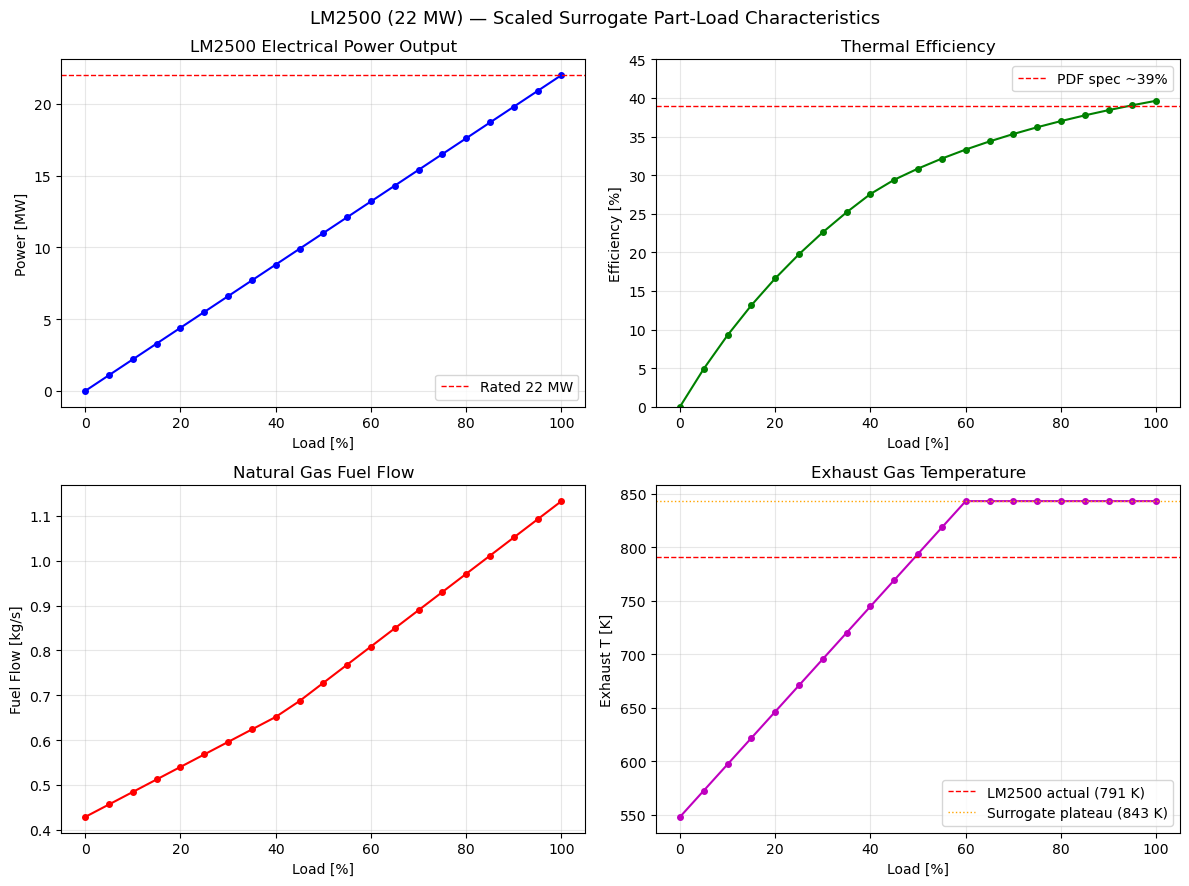

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Power
ax = axes[0, 0]
ax.plot(df['load_frac'] * 100, df['power_mw'], 'b-o', markersize=4)
ax.set_xlabel('Load [%]')
ax.set_ylabel('Power [MW]')
ax.set_title('LM2500 Electrical Power Output')
ax.axhline(22.0, color='r', ls='--', lw=1, label='Rated 22 MW')
ax.legend()
ax.grid(True, alpha=0.3)

# Efficiency
ax = axes[0, 1]
ax.plot(df['load_frac'] * 100, df['efficiency'] * 100, 'g-o', markersize=4)
ax.set_xlabel('Load [%]')
ax.set_ylabel('Efficiency [%]')
ax.set_title('Thermal Efficiency')
ax.axhline(39.0, color='r', ls='--', lw=1, label='PDF spec ~39%')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 45)

# Fuel flow
ax = axes[1, 0]
ax.plot(df['load_frac'] * 100, df['fuel_kg_s'], 'r-o', markersize=4)
ax.set_xlabel('Load [%]')
ax.set_ylabel('Fuel Flow [kg/s]')
ax.set_title('Natural Gas Fuel Flow')
ax.grid(True, alpha=0.3)

# Exhaust temperature
ax = axes[1, 1]
ax.plot(df['load_frac'] * 100, df['exhaust_T_K'], 'm-o', markersize=4)
ax.set_xlabel('Load [%]')
ax.set_ylabel('Exhaust T [K]')
ax.set_title('Exhaust Gas Temperature')
ax.axhline(791, color='r', ls='--', lw=1, label='LM2500 actual (791 K)')
ax.axhline(843, color='orange', ls=':', lw=1, label='Surrogate plateau (843 K)')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle('LM2500 (22 MW) — Scaled Surrogate Part-Load Characteristics', fontsize=13)
fig.tight_layout()
plt.show()

## 5. Time-Series Dispatch (Load17 Preview)

Dispatch the LM2500 against the scaled `Load17` demand profile only.

This gives a steady-state dispatch preview before the full dynamic
swing-equation + TGOV1 integration later in the notebook.

In [63]:
# Load17-only preview profile (scaled demand in MW)
load17_path_preview = ROOT / "Load17"
load17_preview = pd.read_csv(
    load17_path_preview,
    sep=r'\s+',
    header=None,
    names=['time_s', 'demand_raw'],
)
load17_preview['demand_mw'] = load17_preview['demand_raw'] * 10.0

# Convert demand to load fraction on LM2500 rating and clip to [0, 1]
load_frac_preview = np.clip(load17_preview['demand_mw'].values / lm2500.rated_power_mw, 0.0, 1.0)

# Build time-indexed series for dispatch_profile (3-second cadence)
time_index = pd.to_datetime(load17_preview['time_s'], unit='s', origin='2026-01-01')
load_series = pd.Series(load_frac_preview, index=time_index)

# Dispatch over Load17 profile
profile_results = lm2500.dispatch_profile(load_series)

# Keep convenience aliases used in the next plotting cell
t_hours = load17_preview['time_s'].values / 3600.0
load_profile = load_frac_preview

print(f"Load17 file: {load17_path_preview}")
print(f"Profile duration: {load17_preview['time_s'].iloc[-1]/3600:.2f} hours ({len(load17_preview)} points)")
print(f"Demand range: {load17_preview['demand_mw'].min():.2f} – {load17_preview['demand_mw'].max():.2f} MW")
print(f"Load fraction range: {load_profile.min():.3f} – {load_profile.max():.3f}")
print(f"Peak power: {profile_results['power_w'].max()/1e6:.2f} MW")
print(f"Mean power: {profile_results['power_w'].mean()/1e6:.2f} MW")
print(f"Total fuel: {profile_results['fuel_kg_s'].sum() * 3 / 1000:.2f} tonnes (Load17 window)")

Load17 file: /Users/syellapa/Documents/Research/2026/DataCenter/Load17
Profile duration: 7.44 hours (8927 points)
Demand range: 15.05 – 19.50 MW
Load fraction range: 0.684 – 0.886
Peak power: 19.50 MW
Mean power: 17.93 MW
Total fuel: 26.32 tonnes (Load17 window)


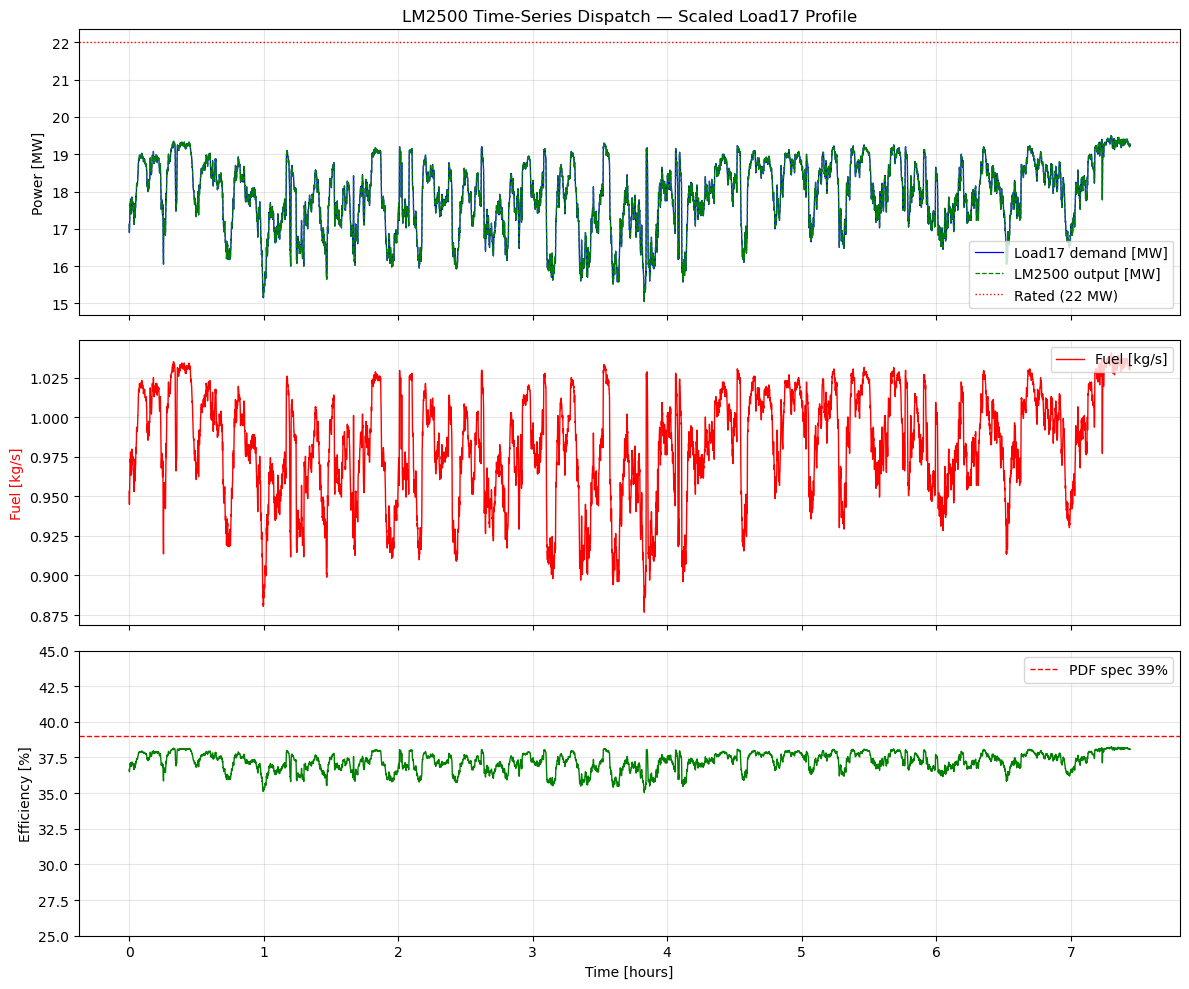

In [33]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Load / Power
ax = axes[0]
ax.plot(t_hours, load17_preview['demand_mw'].values, 'b-', lw=0.9, label='Load17 demand [MW]')
ax.plot(t_hours, profile_results['power_w'].values / 1e6, 'g--', lw=0.9, label='LM2500 output [MW]')
ax.axhline(22.0, color='r', ls=':', lw=1, label='Rated (22 MW)')
ax.set_ylabel('Power [MW]')
ax.set_title('LM2500 Time-Series Dispatch — Scaled Load17 Profile')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Fuel
ax = axes[1]
ax.plot(t_hours, profile_results['fuel_kg_s'].values, 'r-', lw=1.0, label='Fuel [kg/s]')
ax.set_ylabel('Fuel [kg/s]', color='r')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Efficiency
ax = axes[2]
ax.plot(t_hours, profile_results['efficiency'].values * 100, 'g-', lw=1.0)
ax.set_xlabel('Time [hours]')
ax.set_ylabel('Efficiency [%]')
ax.axhline(39.0, color='r', ls='--', lw=1, label='PDF spec 39%')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(25, 45)

fig.tight_layout()
plt.show()

## 6. Summary & Key Parameters for Phase 2

Collect the model parameters that Phase 2 (electrical generator + transient dynamics)
will need from the LM2500 turbine model.

In [43]:
# Parameters carried forward to transient dynamics (direct integration)
lm2500_params = {
    # Turbine
    "rated_power_mw": 22.0,
    "configuration": "two-shaft, free power turbine",
    "power_turbine_speed_rpm": 3600,
    "hp_rotor_speed_range_rpm": (5800, 10000),
    
    # Generator (from PDF)
    "generator_rating_mw": 23.0,
    "generator_type": "3-phase, brushless, water-cooled",
    "frequency_hz": 60,
    "poles": 2,
    
    # Dynamics parameters (aeroderivative-class estimates)
    "inertia_H_s": 2.8,
    "damping_D": 1.0,
    "governor_droop_pct": 4.0,
    "governor_T1_s": 0.15,
    "governor_T2_s": 0.3,
    "governor_T3_s": 1.5,
}

print("LM2500 Parameters for Transient Dynamics")
print("=" * 45)
for key, val in lm2500_params.items():
    print(f"  {key:<35} = {val}")

print()
print("Next steps:")
print("  Phase 3: Load data-center demand profile (Load17)")
print("  Phase 4: Run direct swing-equation + TGOV1 integration")
print("  Phase 5: Post-process frequency, torque, fuel, and fatigue")

LM2500 Parameters for Transient Dynamics
  rated_power_mw                      = 22.0
  configuration                       = two-shaft, free power turbine
  power_turbine_speed_rpm             = 3600
  hp_rotor_speed_range_rpm            = (5800, 10000)
  generator_rating_mw                 = 23.0
  generator_type                      = 3-phase, brushless, water-cooled
  frequency_hz                        = 60
  poles                               = 2
  inertia_H_s                         = 2.8
  damping_D                           = 1.0
  governor_droop_pct                  = 4.0
  governor_T1_s                       = 0.15
  governor_T2_s                       = 0.3
  governor_T3_s                       = 1.5

Next steps:
  Phase 3: Load data-center demand profile (Load17)
  Phase 4: Run direct swing-equation + TGOV1 integration
  Phase 5: Post-process frequency, torque, fuel, and fatigue


## 7. Define LM2500 Generator & Governor Parameters

These parameters reflect an LM2500 aeroderivative gen-set in islanded service.
Key differences from the repo's heavy-duty defaults:
- **Lower inertia** (H=2.8 s vs 5.0 s): lighter rotating mass (power turbine + 2-pole generator)
- **Faster governor** (T1=0.15, T3=1.5 s vs 0.5, 5.0 s): electronic fuel control + free power turbine
- **Tighter droop** (4% vs 5%): common for aeroderivatives in isolated/island service

In [44]:
# ─── LM2500 Machine Parameters (standalone) ──────────────────────────────────
# Keep these as plain values for the direct swing-equation + governor workflow.

# H = 2.8 s: combined power-turbine + generator rotor inertia estimate
# D = 1.0: lumped electromechanical damping coefficient in per-unit model
H_s = 2.8
D_pu = 1.0
M_pu_s = 2.0 * H_s
S_base_mva = 23.0

# Lightweight container for compatibility/readability in downstream notebook cells
lm2500_machine = {
    'H_s': H_s,
    'D': D_pu,
    'M': M_pu_s,
    'S_base_mva': S_base_mva,
}

print('LM2500 machine parameter set (standalone):')
print(f"  H = {lm2500_machine['H_s']:.2f} s")
print(f"  M = 2H = {lm2500_machine['M']:.2f} pu·s")
print(f"  D = {lm2500_machine['D']:.2f} pu/pu")
print(f"  S_base = {lm2500_machine['S_base_mva']:.1f} MVA")
print(f"  Stored kinetic energy @ rated = H*S_base = {H_s * S_base_mva:.1f} MJ")

LM2500 machine parameter set (standalone):
  H = 2.80 s
  M = 2H = 5.60 pu·s
  D = 1.00 pu/pu
  S_base = 23.0 MVA
  Stored kinetic energy @ rated = H*S_base = 64.4 MJ


In [45]:
# ─── LM2500 Governor Parameters (TGOV1, standalone) ──────────────────────────
# The LM2500 uses a Woodward-type electronic governor (MkVIe or NetCon 5000).
# The free power turbine configuration means:
#   - Fuel valve responds to speed error very quickly (T1 = 0.15 s)
#   - Gas-generator HP rotor accelerates/decelerates (T2 = 0.3 s lead compensation)
#   - Hot gas fills the 6-stage power turbine volume (T3 = 1.5 s — the dominant lag)
#
# R = 0.04 (4% droop): tighter than the 5% grid-parallel standard.
#   Aeroderivatives in islanded service (offshore platforms, naval, data centers)
#   typically use 4% or even 3% to minimize steady-state frequency offset.
#
# VMAX = 1.1: transient overload headroom for frequency recovery,
# but limited by thermal/firing constraints.

from types import SimpleNamespace

lm2500_governor = SimpleNamespace(
    R=0.04,      # 4% droop
    T1=0.15,     # speed-governor lag (fast electronic valve)
    T2=0.3,      # lead time constant
    T3=1.5,      # turbine/gas-fill time constant
    Dt=0.0,      # no additional turbine damping (captured in machine D)
    VMAX=1.1,    # max fuel command
    VMIN=0.0,    # min fuel command
)

print('Governor (TGOV1) parameters (standalone):')
print(f"  Droop R = {lm2500_governor.R} ({lm2500_governor.R*100:.0f}%)")
print(f"  T1 = {lm2500_governor.T1} s (fuel valve)")
print(f"  T2 = {lm2500_governor.T2} s (lead)")
print(f"  T3 = {lm2500_governor.T3} s (turbine lag)")
print(f"  VMAX = {lm2500_governor.VMAX} pu, VMIN = {lm2500_governor.VMIN} pu")

Governor (TGOV1) parameters (standalone):
  Droop R = 0.04 (4%)
  T1 = 0.15 s (fuel valve)
  T2 = 0.3 s (lead)
  T3 = 1.5 s (turbine lag)
  VMAX = 1.1 pu, VMIN = 0.0 pu


---
# Phase 3 — Data Center Load Profile (Load17)

## Data Source
- File: `Load17` (tab-separated, no header)
- Column 1: time in seconds (3 s intervals, range 3–26,781 s ≈ 7.4 hours)
- Column 2: electrical demand (×10 scaling → MW)
- 8,927 data points

## Simulation Setup (Direct Integration)
- Single-machine swing equation + TGOV1 governor
- Imposed active power demand: `Pe(t)` from Load17
- Full time window simulated: `t=0` to `t=26,781 s`
- Load changes applied as discrete steps every 3 s (zero-order hold)

**Note:** This setup uses direct ODE integration with `solve_ivp`.

In [46]:
# ─── Load the Load17 data center demand profile ─────────────────────────────
load17_path = ROOT / "Load17"
load17_raw = pd.read_csv(load17_path, sep=r'\s+', header=None, names=['time_s', 'demand_raw'])

# Scale column 2 by 10 to get MW
load17_raw['demand_mw'] = load17_raw['demand_raw'] * 10.0

print(f"Load17 file: {load17_path}")
print(f"  Points:     {len(load17_raw)}")
print(f"  Time range: {load17_raw['time_s'].iloc[0]:.0f} – {load17_raw['time_s'].iloc[-1]:.0f} s "
      f"({load17_raw['time_s'].iloc[-1]/3600:.2f} hours)")
print(f"  Δt:         {load17_raw['time_s'].diff().iloc[1]:.0f} s")
print(f"  Demand range: {load17_raw['demand_mw'].min():.2f} – {load17_raw['demand_mw'].max():.2f} MW")
print(f"  Mean demand:  {load17_raw['demand_mw'].mean():.2f} MW")
print(f"  LM2500 rated: {lm2500.rated_power_mw} MW")
print(f"  Peak load fraction: {load17_raw['demand_mw'].max()/lm2500.rated_power_mw*100:.1f}%")

Load17 file: /Users/syellapa/Documents/Research/2026/DataCenter/Load17
  Points:     8927
  Time range: 3 – 26781 s (7.44 hours)
  Δt:         3 s
  Demand range: 15.05 – 19.50 MW
  Mean demand:  17.93 MW
  LM2500 rated: 22.0 MW
  Peak load fraction: 88.6%


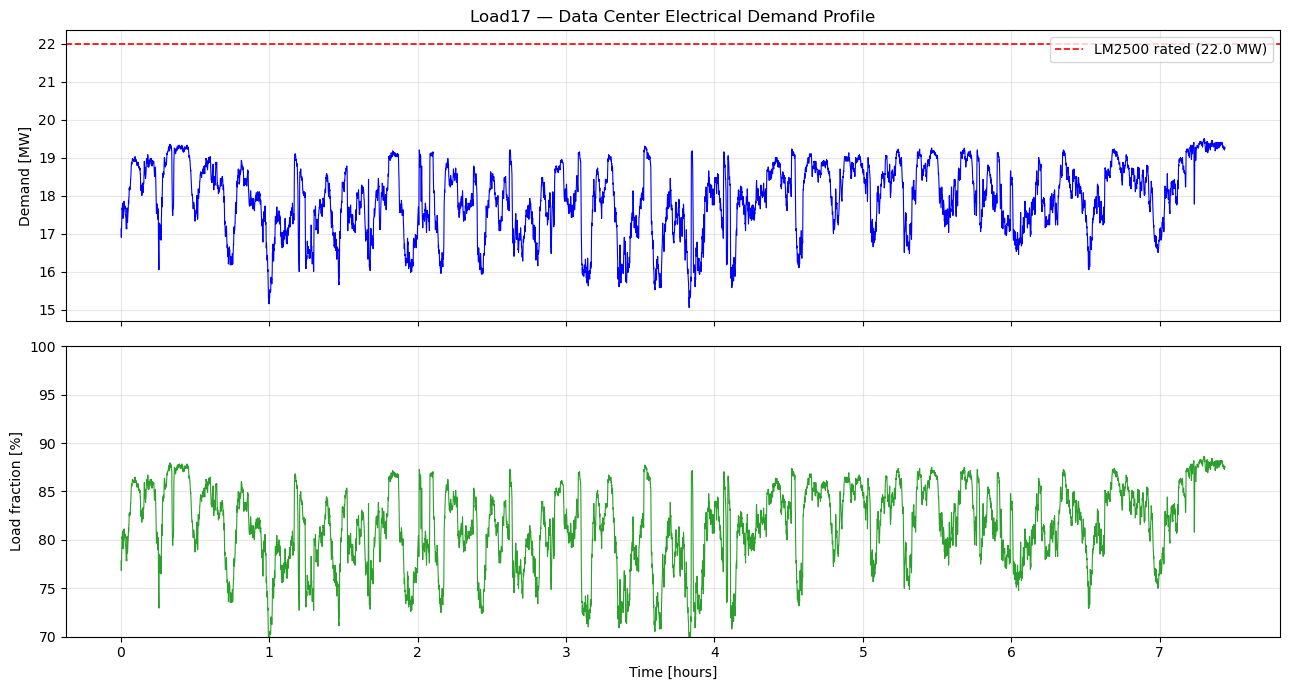

In [16]:
# ─── Preview the demand profile ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.plot(load17_raw['time_s'] / 3600, load17_raw['demand_mw'], 'b-', lw=0.8)
ax.axhline(lm2500.rated_power_mw, color='r', ls='--', lw=1.2, label=f'LM2500 rated ({lm2500.rated_power_mw} MW)')
ax.set_ylabel('Demand [MW]')
ax.set_title('Load17 — Data Center Electrical Demand Profile')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(load17_raw['time_s'] / 3600, load17_raw['demand_mw'] / lm2500.rated_power_mw * 100,
        'C2-', lw=0.8)
ax.set_ylabel('Load fraction [%]')
ax.set_xlabel('Time [hours]')
ax.grid(True, alpha=0.3)
ax.set_ylim(70, 100)

fig.tight_layout()
plt.show()

## 14. Full-Window Results — Frequency, Power, Torque, Fuel

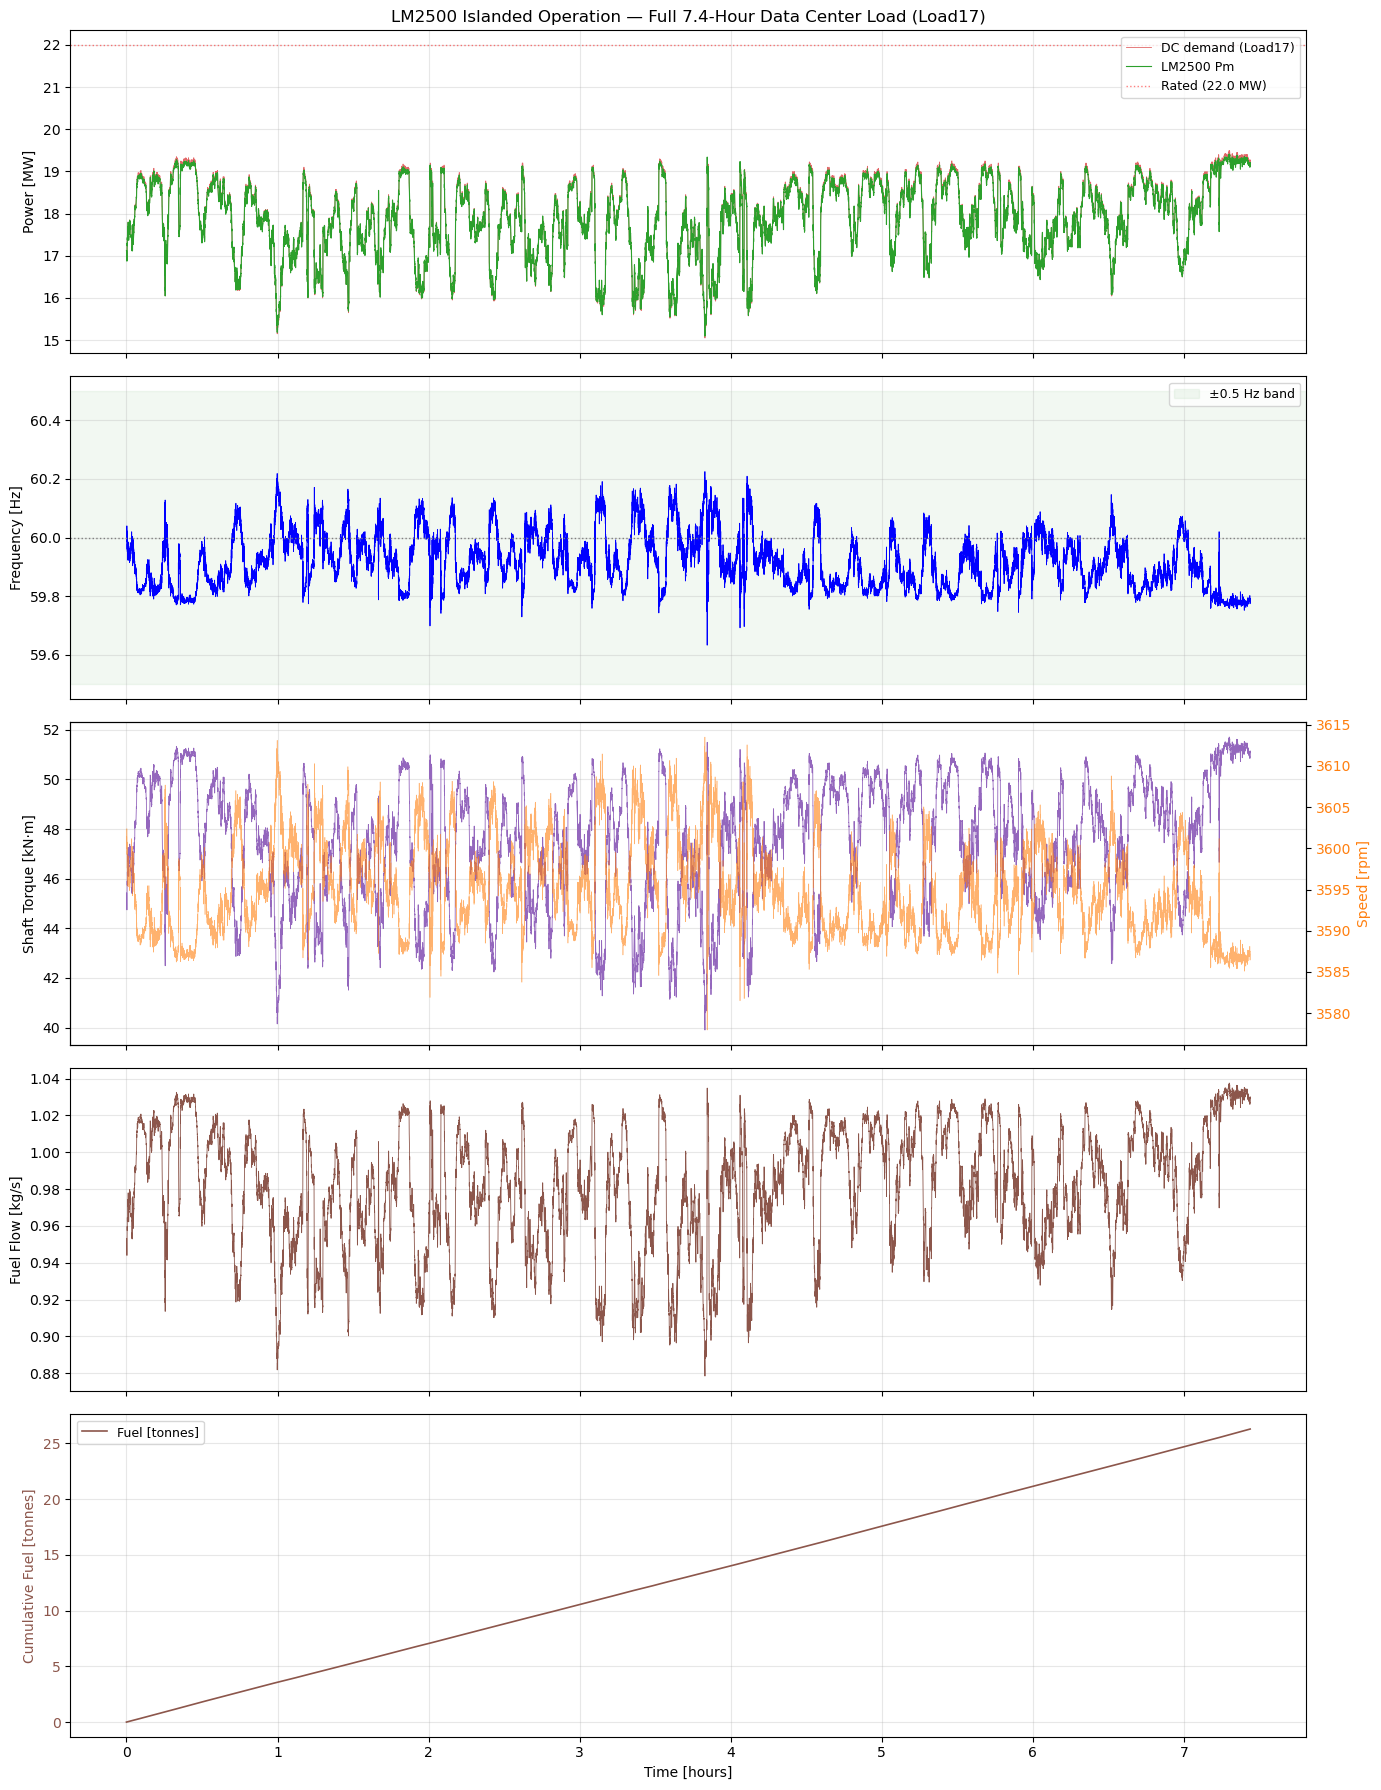


Key metrics over 7.44-hour window:
  Frequency band: 59.6326 – 60.2250 Hz
  Max excursion:  367.4 mHz
  Speed range:    3578.0 – 3613.5 rpm
  Torque range:   39.90 – 51.71 kN·m
  Total fuel:     26.29 tonnes
  Avg fuel rate:  0.982 kg/s


In [35]:
# ─── Plot full-window transient results (direct integration) ─────────────────
t_hr = t_eval / 3600

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

# Panel 1: Imposed load vs generator output
ax = axes[0]
ax.plot(t_hr, Pe_mw, 'C3-', lw=0.6, alpha=0.7, label='DC demand (Load17)')
ax.plot(t_hr, Pm_mw, 'C2-', lw=0.8, label='LM2500 Pm')
ax.axhline(lm2500.rated_power_mw, color='r', ls=':', lw=1, alpha=0.5, label=f'Rated ({lm2500.rated_power_mw} MW)')
ax.set_ylabel('Power [MW]')
ax.set_title('LM2500 Islanded Operation — Full 7.4-Hour Data Center Load (Load17)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: Frequency
ax = axes[1]
ax.plot(t_hr, freq_hz, 'b-', lw=0.6)
ax.axhline(60.0, color='gray', ls=':', lw=1)
ax.axhspan(59.5, 60.5, color='green', alpha=0.05, label='±0.5 Hz band')
ax.set_ylabel('Frequency [Hz]')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 3: Speed (RPM) and Torque
ax = axes[2]
ax.plot(t_hr, torque_kNm_sol, 'C4-', lw=0.6)
ax.set_ylabel('Shaft Torque [kN·m]')
ax.grid(True, alpha=0.3)
ax2 = ax.twinx()
ax2.plot(t_hr, speed_rpm_sol, 'C1-', lw=0.4, alpha=0.6)
ax2.set_ylabel('Speed [rpm]', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

# Panel 4: Fuel flow
ax = axes[3]
ax.plot(t_hr, fuel_sol, 'C5-', lw=0.6)
ax.set_ylabel('Fuel Flow [kg/s]')
ax.grid(True, alpha=0.3)

# Panel 5: Cumulative fuel
ax = axes[4]
ax.plot(t_hr, cum_fuel_kg / 1000, 'C5-', lw=1.2, label='Fuel [tonnes]')
ax.set_ylabel('Cumulative Fuel [tonnes]', color='C5')
ax.tick_params(axis='y', labelcolor='C5')
ax.set_xlabel('Time [hours]')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"\nKey metrics over {t_span[1]/3600:.2f}-hour window:")
print(f"  Frequency band: {freq_hz.min():.4f} – {freq_hz.max():.4f} Hz")
print(f"  Max excursion:  {max(freq_hz.max()-60, 60-freq_hz.min())*1000:.1f} mHz")
print(f"  Speed range:    {speed_rpm_sol.min():.1f} – {speed_rpm_sol.max():.1f} rpm")
print(f"  Torque range:   {torque_kNm_sol.min():.2f} – {torque_kNm_sol.max():.2f} kN·m")
print(f"  Total fuel:     {cum_fuel_kg[-1]/1000:.2f} tonnes")
print(f"  Avg fuel rate:  {fuel_sol.mean():.3f} kg/s")

In [25]:
# ─── Diagnostic: verify direct-integration load tracking ─────────────────────
check_times = [10, 100, 1000, 5000, 10000, 20000, 26000]
print("Time-check: did Pm track demand?")
print(f"{'Time [s]':>10} {'Demand [MW]':>12} {'LM2500 Pm [MW]':>15} {'Δ [MW]':>10}")
print("-" * 52)

for t_check in check_times:
    idx = int(np.argmin(np.abs(t_eval - t_check)))
    demand_at_t = Pe_mw[idx]
    pm_at_t = Pm_mw[idx]
    print(f"{t_check:>10} {demand_at_t:>12.2f} {pm_at_t:>15.2f} {pm_at_t - demand_at_t:>10.2f}")

print(f"\nPm range: {Pm_mw.min():.2f} – {Pm_mw.max():.2f} MW")
print(f"Demand range: {Pe_mw.min():.2f} – {Pe_mw.max():.2f} MW")
print(f"Frequency range: {freq_hz.min():.4f} – {freq_hz.max():.4f} Hz")

Time-check: did Pm track demand?
  Time [s]  Demand [MW]  LM2500 Pm [MW]     Δ [MW]
----------------------------------------------------
        10        16.90           16.91       0.01
       100        17.73           17.70      -0.02
      1000        17.82           17.81      -0.02
      5000        18.45           18.38      -0.07
     10000        16.95           16.97       0.02
     20000        17.45           17.46       0.01
     26000        19.10           19.00      -0.10

Pm range: 15.10 – 19.42 MW
Demand range: 15.05 – 19.50 MW
Frequency range: 59.6326 – 60.2250 Hz


## 15. Direct Integration — Swing Equation + TGOV1 with Time-Varying Load

**Model equations** (per-unit on machine base `Sn = 23 MVA`):

$$M \frac{d\omega}{dt} = P_m - P_e(t) - D(\omega - 1)$$

$$\frac{d\delta}{dt} = \omega_0 (\omega - 1)$$

**TGOV1 governor (implemented form):**
- Governor input: $u_g = P_{ref} + \frac{1}{R}(1-\omega)$
- Lag state: $\dot{x}_1 = \frac{1}{T_1}(u_g - x_1)$
- Lead-lag output: $P_{valve} = x_1 + T_2\dot{x}_1$, then clamp to $[V_{min},V_{max}]$
- Turbine lag: $\dot{P}_m = \frac{1}{T_3}(P_{valve} - P_m)$

`P_e(t)` is built from the Load17 profile via zero-order hold interpolation.

In [64]:
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# ─── LM2500 parameters (per-unit on Sn = 23 MVA base) ───────────────────────
Sn_mva = 23.0          # machine MVA base
H = 2.8                 # inertia constant [s]
M = 2 * H              # M = 2H
D = 1.0                 # damping [pu/pu]
R = 0.04               # droop
T1 = 0.15              # governor lag [s]
T2 = 0.3               # governor lead [s]
T3 = 1.5               # turbine lag [s]
VMAX = 1.1             # max fuel command [pu]
VMIN = 0.0             # min fuel command [pu]
omega_0 = 2 * np.pi * 60  # rad/s (for delta equation)

# ─── Build load interpolant from Load17 ─────────────────────────────────────
# Convert demand to per-unit on machine base
load_time = load17_raw['time_s'].values
load_pu = load17_raw['demand_mw'].values / Sn_mva  # pu on 23 MVA base

# Extend to t=0 (use first value for the grid-tied preamble)
load_time_ext = np.concatenate([[0.0], load_time])
load_pu_ext = np.concatenate([[load_pu[0]], load_pu])

# Interpolant: step-hold (zero-order hold matches discrete 3-s updates)
Pe_interp = interp1d(load_time_ext, load_pu_ext, kind='zero', 
                     bounds_error=False, fill_value=(load_pu[0], load_pu[-1]))

# Initial conditions: steady state at first load point
Pe0 = load_pu[0]
Pm0 = Pe0              # in steady state Pm = Pe (no acceleration)
omega0 = 1.0           # nominal speed [pu]
delta0 = 0.0           # arbitrary reference angle
x1_0 = Pm0             # governor state in steady state

print(f"Machine base: {Sn_mva} MVA")
print(f"Initial load: {Pe0*Sn_mva:.2f} MW = {Pe0:.4f} pu")
print(f"Initial Pm:   {Pm0*Sn_mva:.2f} MW = {Pm0:.4f} pu")
print(f"H={H} s, D={D}, R={R}, T1={T1} s, T2={T2} s, T3={T3} s")

Machine base: 23.0 MVA
Initial load: 17.12 MW = 0.7446 pu
Initial Pm:   17.12 MW = 0.7446 pu
H=2.8 s, D=1.0, R=0.04, T1=0.15 s, T2=0.3 s, T3=1.5 s


In [65]:
# ─── ODE system: swing equation + TGOV1 governor ────────────────────────────
# State vector: [delta, omega, x1 (governor lag state), Pm (turbine output)]
# Pref = initial mechanical power reference (closure over Pe0)

import time as _time

Pref = Pe0   # power reference for the governor (pu)

def lm2500_ode(t, y):
    """LM2500 single-machine dynamics with TGOV1 governor and time-varying load."""
    delta, omega, x1, Pm = y
    
    # Electrical load (time-varying from Load17)
    Pe = float(Pe_interp(t))
    
    # Swing equation: M dω/dt = Pm - Pe - D(ω - 1)
    domega_dt = (Pm - Pe - D * (omega - 1.0)) / M
    
    # Rotor angle (for completeness; not critical for frequency-only studies)
    ddelta_dt = omega_0 * (omega - 1.0)
    
    # TGOV1 Governor:
    # Stage 1: governor input = Pref + speed_error/droop → first-order lag
    gov_input = Pref + (1.0 - omega) / R
    dx1_dt = (gov_input - x1) / T1
    
    # Stage 2: lead-lag output
    P_valve = x1 + T2 * dx1_dt
    
    # Clamp valve position
    P_valve = np.clip(P_valve, VMIN, VMAX)
    
    # Stage 3: turbine lag
    dPm_dt = (P_valve - Pm) / T3
    
    return [ddelta_dt, domega_dt, dx1_dt, dPm_dt]

# ─── Simulate the full Load17 window ────────────────────────────────────────
t_span = (0.0, float(load17_raw['time_s'].iloc[-1]))
y0 = [delta0, omega0, x1_0, Pm0]

print(f"Pref = {Pref:.4f} pu ({Pref*Sn_mva:.2f} MW)")
print(f"Integrating from t=0 to t={t_span[1]:.0f} s ({t_span[1]/3600:.2f} hr)...")
print(f"  States: [delta, omega, x1_governor, Pm]")
print(f"  Forcing: Pe(t) from Load17 (zero-order hold interpolation)")

t_start_ode = _time.time()
sol = solve_ivp(
    lm2500_ode, t_span, y0,
    method='RK45',
    max_step=1.0,       # max 1 s step (captures 3-s load changes)
    rtol=1e-6, atol=1e-8,
    dense_output=True,
)
elapsed_ode = _time.time() - t_start_ode

print(f"\nIntegration complete in {elapsed_ode:.1f} s")
print(f"  Solver steps: {sol.t.size}")
print(f"  Success: {sol.success}")
if not sol.success:
    print(f"  Message: {sol.message}")

Pref = 0.7446 pu (17.12 MW)
Integrating from t=0 to t=26781 s (7.44 hr)...
  States: [delta, omega, x1_governor, Pm]
  Forcing: Pe(t) from Load17 (zero-order hold interpolation)

Integration complete in 13.4 s
  Solver steps: 105344
  Success: True


In [66]:
# ─── Post-process: evaluate solution on a uniform grid ───────────────────────
# Sample at 1-s intervals for plotting (26,781 points — manageable)
t_eval = np.arange(0, t_span[1] + 1, 1.0)
y_eval = sol.sol(t_eval)  # dense output evaluation

delta_sol = y_eval[0]
omega_sol = y_eval[1]     # per-unit speed
x1_sol = y_eval[2]
Pm_sol = y_eval[3]        # per-unit mechanical power

# Convert to physical units
freq_hz = omega_sol * 60.0                     # Hz
speed_rpm_sol = freq_hz * 60.0                 # rpm
Pm_mw = Pm_sol * Sn_mva                       # MW
Pe_mw = np.array([float(Pe_interp(t)) for t in t_eval]) * Sn_mva  # MW

# Torque: T = P / ω (physical)
omega_phys = 2 * np.pi * freq_hz
torque_kNm_sol = (Pm_mw * 1e6) / omega_phys / 1000  # kN·m

# Fuel via gas_plant surrogate (dispatch at inferred load fraction)
load_frac_sol = np.clip(Pm_mw / lm2500.rated_power_mw, 0, 1)
dispatch_sol = lm2500.dispatch(load_frac_sol)
fuel_sol = dispatch_sol['fuel_kg_s']

# Cumulative fuel (trapezoidal)
cum_fuel_kg = np.concatenate([[0], np.cumsum(0.5 * (fuel_sol[1:] + fuel_sol[:-1]) * np.diff(t_eval))])

print("Post-processing complete.")
print(f"  Frequency range: {freq_hz.min():.4f} – {freq_hz.max():.4f} Hz")
print(f"  Max Δf:          {max(freq_hz.max()-60, 60-freq_hz.min())*1000:.1f} mHz")
print(f"  Speed range:     {speed_rpm_sol.min():.1f} – {speed_rpm_sol.max():.1f} rpm")
print(f"  Torque range:    {torque_kNm_sol.min():.2f} – {torque_kNm_sol.max():.2f} kN·m")
print(f"  Pm range:        {Pm_mw.min():.2f} – {Pm_mw.max():.2f} MW")
print(f"  Total fuel:      {cum_fuel_kg[-1]/1000:.2f} tonnes")

Post-processing complete.
  Frequency range: 59.6326 – 60.2250 Hz
  Max Δf:          367.4 mHz
  Speed range:     3578.0 – 3613.5 rpm
  Torque range:    39.90 – 51.71 kN·m
  Pm range:        15.10 – 19.42 MW
  Total fuel:      26.29 tonnes


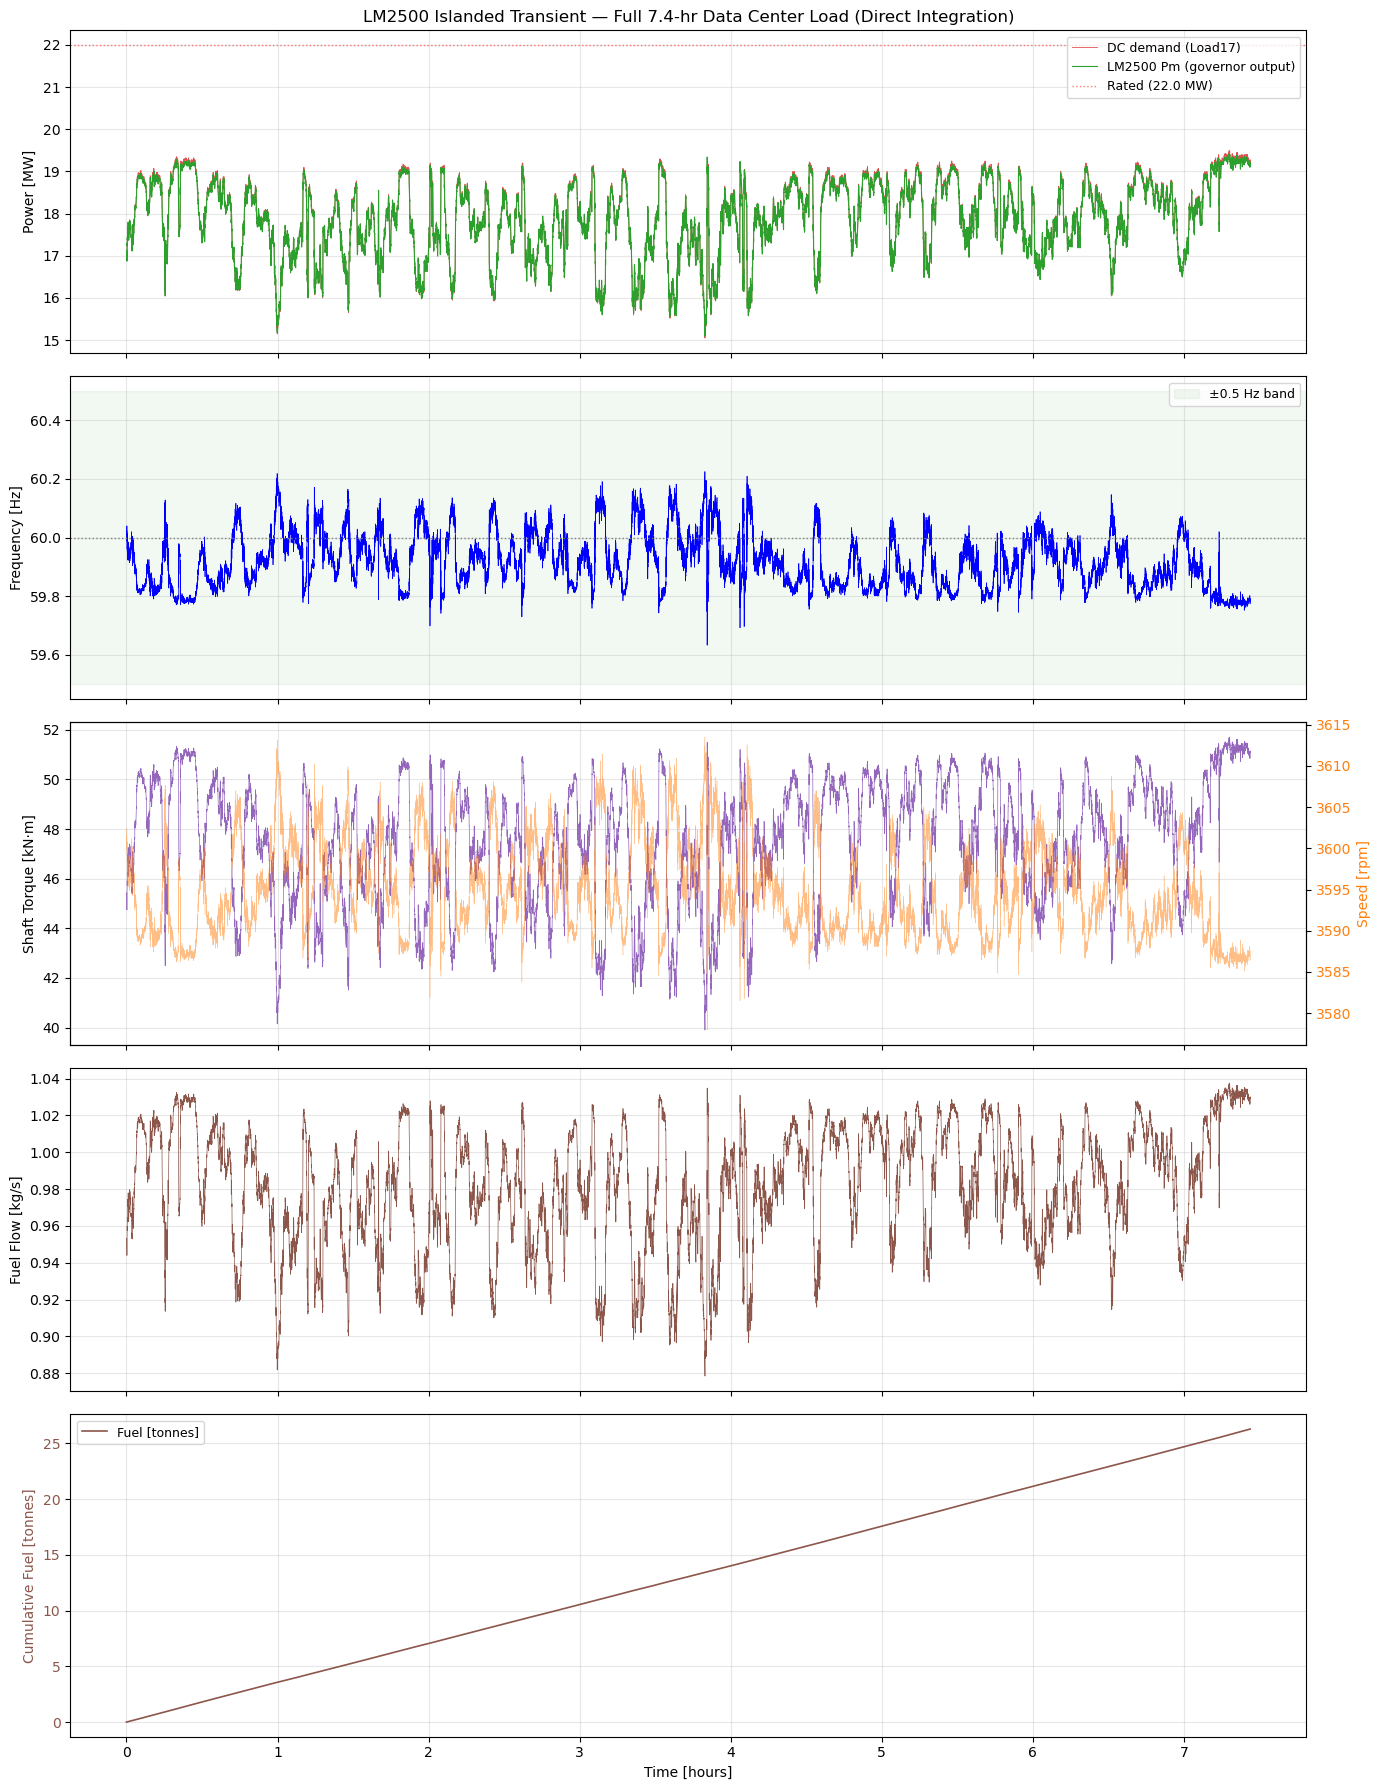

In [67]:
# ─── Full-window plots with proper load tracking ────────────────────────────
t_hr_sol = t_eval / 3600

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

# Panel 1: Power — demand vs generator output
ax = axes[0]
ax.plot(t_hr_sol, Pe_mw, 'C3-', lw=0.6, alpha=0.8, label='DC demand (Load17)')
ax.plot(t_hr_sol, Pm_mw, 'C2-', lw=0.8, label='LM2500 Pm (governor output)')
ax.axhline(lm2500.rated_power_mw, color='r', ls=':', lw=1, alpha=0.5, label=f'Rated ({lm2500.rated_power_mw} MW)')
ax.set_ylabel('Power [MW]')
ax.set_title('LM2500 Islanded Transient — Full 7.4-hr Data Center Load (Direct Integration)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: Frequency
ax = axes[1]
ax.plot(t_hr_sol, freq_hz, 'b-', lw=0.5)
ax.axhline(60.0, color='gray', ls=':', lw=1)
ax.axhspan(59.5, 60.5, color='green', alpha=0.05, label='±0.5 Hz band')
ax.set_ylabel('Frequency [Hz]')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 3: Shaft torque and speed
ax = axes[2]
ax.plot(t_hr_sol, torque_kNm_sol, 'C4-', lw=0.5)
ax.set_ylabel('Shaft Torque [kN·m]')
ax.grid(True, alpha=0.3)
ax2 = ax.twinx()
ax2.plot(t_hr_sol, speed_rpm_sol, 'C1-', lw=0.3, alpha=0.5)
ax2.set_ylabel('Speed [rpm]', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

# Panel 4: Fuel flow
ax = axes[3]
ax.plot(t_hr_sol, fuel_sol, 'C5-', lw=0.5)
ax.set_ylabel('Fuel Flow [kg/s]')
ax.grid(True, alpha=0.3)

# Panel 5: Cumulative fuel
ax = axes[4]
ax.plot(t_hr_sol, cum_fuel_kg / 1000, 'C5-', lw=1.2, label='Fuel [tonnes]')
ax.set_ylabel('Cumulative Fuel [tonnes]', color='C5')
ax.tick_params(axis='y', labelcolor='C5')
ax.set_xlabel('Time [hours]')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Phase 4 — Shaft Fatigue Screening via Rainflow Counting + Miner's Rule

This section adds a **torsional-fatigue screening workflow** using the simulated shaft torque
`torque_kNm_sol(t)` from Phase 3.

### Why this is needed

Even when turbine speed remains close to 3600 rpm, repeated load-following events produce
repeated **torque ranges** on the shaft train (turbine-coupling-generator). Fatigue damage
is driven by stress/torque cycles, not just mean speed.

### What is implemented

1. **Signal conditioning + turning points extraction**
   - Start from torque history `T(t)` in kN·m
   - Remove consecutive duplicates
   - Reduce to turning points (peaks/valleys), which preserve fatigue-relevant reversals

2. **Rainflow counting (ASTM-style stack method)**
   - Use a 4-point stack algorithm to identify closed hysteresis loops
   - Emit:
     - `count = 1.0` for closed full cycles
     - `count = 0.5` for residual open half cycles at the ends
   - For each counted cycle compute:
     - range: `ΔT = |T2 - T1|`
     - amplitude: `Ta = ΔT/2`
     - mean torque: `Tm = (T1 + T2)/2`

3. **Convert torque cycles to stress-like cycles (screening-level)**
   - For a circular shaft, shear stress scales linearly with torque:
     - `τ = Kτ * T`
   - If exact geometry is unavailable, use a **relative analysis** by setting `Kτ = 1`
     and carrying torque range directly into Basquin S-N scaling.

4. **Cycle life model (Basquin power law)**
   - Use stress/torque amplitude relation:
     - `Nf = (Sa_ref / Sa)^m`
   - `m` is fatigue slope (typical steel torsion screening: 4–8; default here `m = 5`)
   - `Sa_ref` is a reference amplitude tied to a chosen reference life `N_ref`

5. **Miner linear cumulative damage**
   - For each cycle bin `i`:
     - `di = ni / Nf_i`
   - Total damage index:
     - `D = Σ di`
   - Interpretation:
     - `D < 1`: below assumed life usage
     - `D ≈ 1`: consumed reference fatigue life
     - `D > 1`: exceeds assumed life at selected S-N parameters

### Important assumptions and limitations

- This is a **screening metric**, not a certified life assessment.
- No mean-stress correction (Goodman/Gerber/Soderberg) is applied by default.
- No notch factor, surface finish, size effect, residual stress, temperature gradient,
  multiaxiality, or transient thermal stress correction is included.
- For design-grade life prediction, replace with actual shaft geometry, material S-N data,
  stress concentration factors, and duty-cycle aggregation across startup/shutdown events.

### Outputs generated below

- Table of largest counted torque ranges
- Rainflow cycle histogram (range vs counts)
- Damage contribution by torque-range bin
- Cumulative damage vs time (using cycle closure time stamp)
- Final Miner's damage index for this 7.44-hour Load17 window

In [58]:
# ─── Rainflow utilities + damage model parameters ────────────────────────────
import math

# Fatigue model parameters (screening defaults)
m_fatigue = 5.0               # Basquin slope (dimensionless)
N_ref = 1e7                   # Reference cycles-to-failure at Sa_ref
Sa_ref = 5.0                  # Reference torque amplitude [kN·m] for N_ref (screening value)

# Optional stress conversion factor (tau = Ktau * T). Keep 1.0 for relative-torque analysis.
Ktau = 1.0

def _compress_consecutive_duplicates(x):
    """Remove consecutive duplicates to avoid zero-range pseudo-cycles."""
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return x
    keep = np.ones_like(x, dtype=bool)
    keep[1:] = x[1:] != x[:-1]
    return x[keep]

def _turning_points(x):
    """Extract turning points (peaks/valleys), preserving endpoints."""
    x = _compress_consecutive_duplicates(x)
    if x.size < 3:
        return x

    tp = [x[0]]
    for i in range(1, len(x) - 1):
        prev_, cur_, next_ = x[i - 1], x[i], x[i + 1]
        # Local extrema criterion (strict sign change in slope)
        if (cur_ > prev_ and cur_ >= next_) or (cur_ < prev_ and cur_ <= next_):
            tp.append(cur_)
    tp.append(x[-1])
    return np.asarray(tp, dtype=float)

def rainflow_count_ranges_means(signal, times=None):
    """Rainflow count using a stack method.

    Returns a DataFrame with one row per cycle:
      range, amplitude, mean, count (1.0 full, 0.5 half), t_close (s)
    """
    x = np.asarray(signal, dtype=float)
    if times is None:
        times = np.arange(len(x), dtype=float)
    times = np.asarray(times, dtype=float)

    # Reduce to turning points with corresponding times
    x_comp = _compress_consecutive_duplicates(x)
    t_comp = times[np.r_[True, x[1:] != x[:-1]]] if len(x) > 1 else times

    if x_comp.size < 3:
        return pd.DataFrame(columns=['range', 'amplitude', 'mean', 'count', 't_close'])

    idx_tp = [0]
    for i in range(1, len(x_comp) - 1):
        prev_, cur_, next_ = x_comp[i - 1], x_comp[i], x_comp[i + 1]
        if (cur_ > prev_ and cur_ >= next_) or (cur_ < prev_ and cur_ <= next_):
            idx_tp.append(i)
    idx_tp.append(len(x_comp) - 1)

    tp = x_comp[idx_tp]
    tt = t_comp[idx_tp]

    stack_vals = []
    stack_times = []
    cycles = []

    for v, t in zip(tp, tt):
        stack_vals.append(v)
        stack_times.append(t)

        while len(stack_vals) >= 3:
            s0 = abs(stack_vals[-2] - stack_vals[-3])
            s1 = abs(stack_vals[-1] - stack_vals[-2])

            # Close cycle when newer range is greater/equal to previous range
            if s1 >= s0:
                rng = s0
                amp = 0.5 * rng
                mean = 0.5 * (stack_vals[-3] + stack_vals[-2])

                # Full cycle for interior extraction, half at beginning boundary
                cnt = 1.0 if len(stack_vals) > 3 else 0.5
                t_close = stack_times[-2]

                cycles.append((rng, amp, mean, cnt, t_close))

                # Remove the closed pair from middle of stack
                del stack_vals[-3:-1]
                del stack_times[-3:-1]
            else:
                break

    # Residual half cycles
    for i in range(len(stack_vals) - 1):
        rng = abs(stack_vals[i + 1] - stack_vals[i])
        amp = 0.5 * rng
        mean = 0.5 * (stack_vals[i + 1] + stack_vals[i])
        cnt = 0.5
        t_close = stack_times[i + 1]
        cycles.append((rng, amp, mean, cnt, t_close))

    out = pd.DataFrame(cycles, columns=['range', 'amplitude', 'mean', 'count', 't_close'])
    out = out.sort_values('t_close').reset_index(drop=True)
    return out

def miners_damage_from_cycles(cycles_df, Sa_ref, N_ref, m, Ktau=1.0):
    """Compute per-cycle life and Miner's damage using Basquin scaling."""
    out = cycles_df.copy()

    # Convert torque amplitude to stress-like amplitude (screening proportionality)
    Sa = Ktau * out['amplitude'].values

    # Avoid divide-by-zero for zero-amplitude cycles
    Sa_eff = np.clip(Sa, 1e-12, None)

    # Basquin: Nf = N_ref * (Sa_ref / Sa)^m
    Nf = N_ref * (Sa_ref / Sa_eff) ** m

    # Damage per counted cycle entry: d = n / Nf
    d_i = out['count'].values / Nf

    out['Sa_equiv'] = Sa
    out['Nf'] = Nf
    out['d_i'] = d_i
    out['D_cum'] = np.cumsum(d_i)
    return out

print('Rainflow and Miner utility functions loaded.')
print(f'Fatigue parameters: m={m_fatigue}, N_ref={N_ref:.2e}, Sa_ref={Sa_ref:.2f} kN·m, Ktau={Ktau:.2f}')

Rainflow and Miner utility functions loaded.
Fatigue parameters: m=5.0, N_ref=1.00e+07, Sa_ref=5.00 kN·m, Ktau=1.00


In [59]:
# ─── Run rainflow counting and compute Miner's damage ────────────────────────
# Input signal for fatigue screening
T_series = torque_kNm_sol
T_time_s = t_eval

# Count torque cycles
cycles_raw = rainflow_count_ranges_means(T_series, times=T_time_s)

# Compute damage metrics
cycles_damage = miners_damage_from_cycles(
    cycles_raw,
    Sa_ref=Sa_ref,
    N_ref=N_ref,
    m=m_fatigue,
    Ktau=Ktau,
)

D_total = float(cycles_damage['d_i'].sum())
T_range_max = float(cycles_damage['range'].max()) if len(cycles_damage) else 0.0
T_amp_max = float(cycles_damage['amplitude'].max()) if len(cycles_damage) else 0.0

# Equivalent life consumption rate for this 7.44-hour window
window_hours = (T_time_s[-1] - T_time_s[0]) / 3600.0
D_per_day = D_total * (24.0 / window_hours)
D_per_year = D_total * (24.0 * 365.0 / window_hours)

print('Rainflow cycle counting complete.')
print(f'  Counted cycle entries: {len(cycles_damage):,}')
print(f'  Max torque range:      {T_range_max:.3f} kN·m')
print(f'  Max torque amplitude:  {T_amp_max:.3f} kN·m')
print('')
print('Miner damage results (screening basis):')
print(f'  D_total (7.44 hr):     {D_total:.6e}')
print(f'  D/day equivalent:      {D_per_day:.6e}')
print(f'  D/year equivalent:     {D_per_year:.6e}')

# Show top contributing cycle entries
top_cycles = cycles_damage.sort_values('d_i', ascending=False).head(12).copy()
cols = ['range', 'amplitude', 'mean', 'count', 't_close', 'Nf', 'd_i', 'D_cum']
print('\nTop cycle contributions (largest d_i):')
display(top_cycles[cols].round({
    'range': 4,
    'amplitude': 4,
    'mean': 4,
    'count': 1,
    't_close': 1,
    'Nf': 3,
    'd_i': 12,
    'D_cum': 12,
}))

# Bin-wise damage breakdown by torque range
nbins = 20
if len(cycles_damage):
    bins = np.linspace(0.0, cycles_damage['range'].max() * 1.001, nbins + 1)
    cycles_damage['range_bin'] = pd.cut(cycles_damage['range'], bins=bins, include_lowest=True)

    damage_by_bin = cycles_damage.groupby('range_bin', observed=False).agg(
        n_entries=('range', 'count'),
        count_sum=('count', 'sum'),
        range_mean=('range', 'mean'),
        d_bin=('d_i', 'sum'),
    ).reset_index()

    damage_by_bin['damage_fraction'] = damage_by_bin['d_bin'] / max(D_total, 1e-30)
    damage_by_bin = damage_by_bin.sort_values('d_bin', ascending=False)

    print('\nTop torque-range bins by damage contribution:')
    display(damage_by_bin.head(10).round({
        'count_sum': 1,
        'range_mean': 4,
        'd_bin': 12,
        'damage_fraction': 6,
    }))

summary_fatigue = {
    'cycles_counted': int(len(cycles_damage)),
    'max_range_kNm': T_range_max,
    'max_amp_kNm': T_amp_max,
    'D_total_window': D_total,
    'D_per_day': D_per_day,
    'D_per_year': D_per_year,
    'm': m_fatigue,
    'Sa_ref_kNm': Sa_ref,
    'N_ref': N_ref,
}
print('\nFatigue summary dict:')
print(summary_fatigue)

Rainflow cycle counting complete.
  Counted cycle entries: 7,316
  Max torque range:      11.429 kN·m
  Max torque amplitude:  5.715 kN·m

Miner damage results (screening basis):
  D_total (7.44 hr):     1.186684e-06
  D/day equivalent:      3.828441e-06
  D/year equivalent:     1.397381e-03

Top cycle contributions (largest d_i):


,range,amplitude,mean,count,t_close,Nf,d_i,D_cum
3477,11.0831,5.5416,45.6892,1.0,12710.0,5.979852e+06,1.672280e-07,6.784650e-07
3776,11.4294,5.7147,45.6155,0.5,13787.0,5.127308e+06,9.751700e-08,8.057170e-07
4002,9.8766,4.9383,46.2670,1.0,14624.0,1.064071e+07,9.397900e-08,9.026660e-07
3104,9.7118,4.8559,46.1332,1.0,11339.0,1.157419e+07,8.639900e-08,4.391150e-07
3300,9.3185,4.6592,46.0107,1.0,12086.0,1.423213e+07,7.026400e-08,5.100400e-07
1437,9.1406,4.5703,46.0794,1.0,5291.0,1.567242e+07,6.380600e-08,1.430110e-07
4059,10.2615,5.1307,46.3618,0.5,14822.0,8.789340e+06,5.688700e-08,9.901350e-07
2574,8.6883,4.3441,46.5847,1.0,9434.0,2.019882e+07,4.950800e-08,3.110430e-07
1914,8.5171,4.2585,46.6111,1.0,7031.0,2.231230e+07,4.481800e-08,2.192380e-07
6416,8.4881,4.2440,46.8187,1.0,23483.0,2.269616e+07,4.406000e-08,1.163343e-06



Top torque-range bins by damage contribution:


,range_bin,n_entries,count_sum,range_mean,d_bin,damage_fraction
19,"(10.869, 11.441]",2,1.5,11.2562,2.647450e-07,0.223097
14,"(8.009, 8.581]",6,5.5,8.2625,2.150900e-07,0.181253
16,"(9.153, 9.725]",2,2.0,9.5152,1.566630e-07,0.132017
17,"(9.725, 10.297]",2,1.5,10.0690,1.508660e-07,0.127132
12,"(6.864, 7.437]",6,6.0,7.3127,1.255590e-07,0.105806
15,"(8.581, 9.153]",2,2.0,8.9144,1.133140e-07,0.095488
13,"(7.437, 8.009]",2,2.0,7.8493,5.960600e-08,0.050229
11,"(6.292, 6.864]",2,2.0,6.7523,2.811400e-08,0.023692
10,"(5.72, 6.292]",3,3.0,5.9626,2.273800e-08,0.019161
8,"(4.576, 5.148]",6,6.0,4.8667,1.648800e-08,0.013894



Fatigue summary dict:
{'cycles_counted': 7316, 'max_range_kNm': 11.429365566861392, 'max_amp_kNm': 5.714682783430696, 'D_total_window': 1.1866838914070225e-06, 'D_per_day': np.float64(3.8284413658028725e-06), 'D_per_year': np.float64(0.0013973810985180488), 'm': 5.0, 'Sa_ref_kNm': 5.0, 'N_ref': 10000000.0}


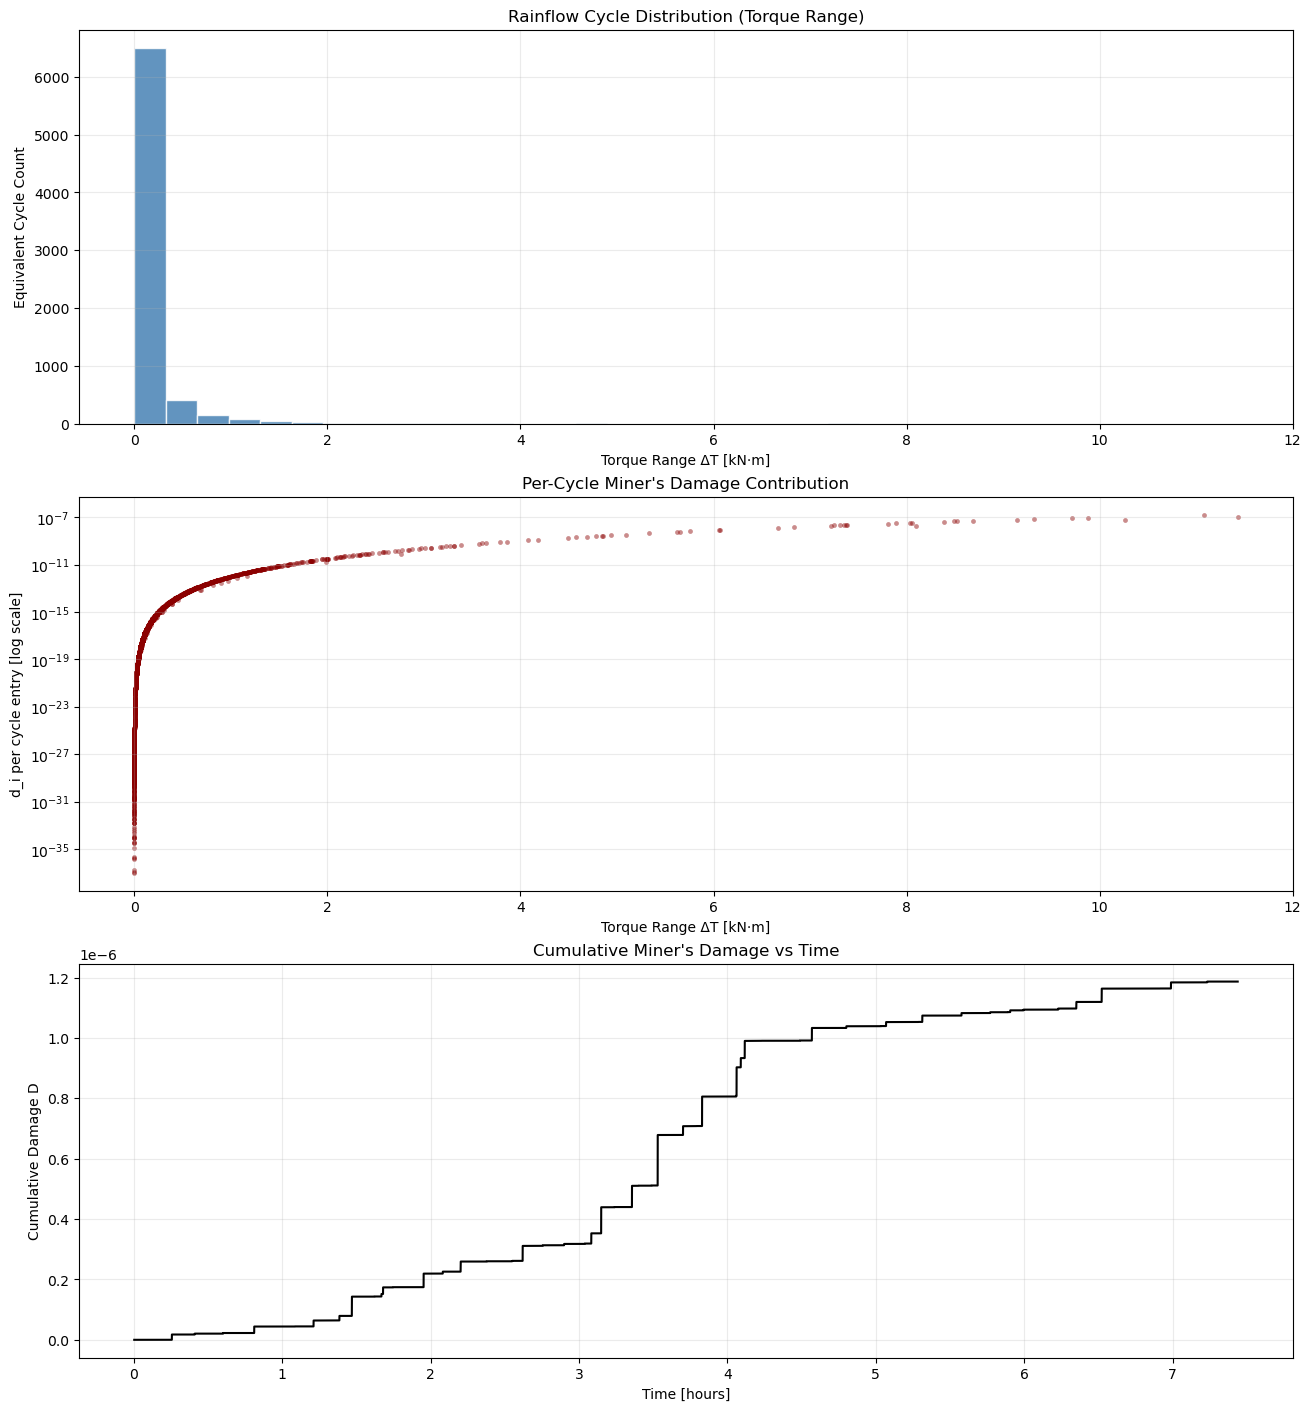

In [53]:
# ─── Visualize rainflow cycles and damage accumulation ───────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 14), constrained_layout=True)

# 1) Histogram of cycle ranges weighted by count
ax = axes[0]
ax.hist(
    cycles_damage['range'],
    bins=35,
    weights=cycles_damage['count'],
    color='steelblue',
    alpha=0.85,
    edgecolor='white',
)
ax.set_title('Rainflow Cycle Distribution (Torque Range)')
ax.set_xlabel('Torque Range ΔT [kN·m]')
ax.set_ylabel('Equivalent Cycle Count')
ax.grid(True, alpha=0.25)

# 2) Damage density by cycle range (scatter)
ax = axes[1]
ax.scatter(
    cycles_damage['range'],
    cycles_damage['d_i'],
    s=12,
    alpha=0.45,
    color='darkred',
    linewidths=0,
)
ax.set_yscale('log')
ax.set_title("Per-Cycle Miner's Damage Contribution")
ax.set_xlabel('Torque Range ΔT [kN·m]')
ax.set_ylabel('d_i per cycle entry [log scale]')
ax.grid(True, alpha=0.25)

# 3) Cumulative damage vs time
ax = axes[2]
t_hr_cycle = cycles_damage['t_close'] / 3600.0
ax.plot(t_hr_cycle, cycles_damage['D_cum'], color='black', lw=1.5)
ax.set_title("Cumulative Miner's Damage vs Time")
ax.set_xlabel('Time [hours]')
ax.set_ylabel('Cumulative Damage D')
ax.grid(True, alpha=0.25)

plt.show()